#PAGERANK USING LINK ANALYSIS

In [1]:
# page rank for link analysis using python.

# importing libraries
import numpy as np
import random
import networkx as nx

In [2]:
# Add edges to the graph
def add_edges(g, p):
    for i in g.nodes():
        for j in g.nodes():
            if i != j:
                r = random.random()
                if r <= p:
                    g.add_edge(i, j)
                else:
                    continue
    return g

In [3]:
# Sort the nodes
def sort_nodes(g, points):
    t = np.array(points)
    t = np.argsort(-t)
    return t

In [4]:
# Distribute the points randomly in a graph
def randome_walk(g):
    nodes = list(g.nodes())
    points = [0 for i in range(g.number_of_nodes())]
    r = random.choice(nodes)
    points[r] += 1
    out = list(g.out_edges(r))  # Convert OutEdgeDataView to a list
    c = 0
    while c != 100000:
        if len(out) == 0:
            focus = random.choice(nodes)
        else:
            r1 = random.choice(out)
            focus = r1[1]
        points[focus] += 1
        out = list(g.out_edges(focus))  # Convert OutEdgeDataView to a list
        c += 1
    return points

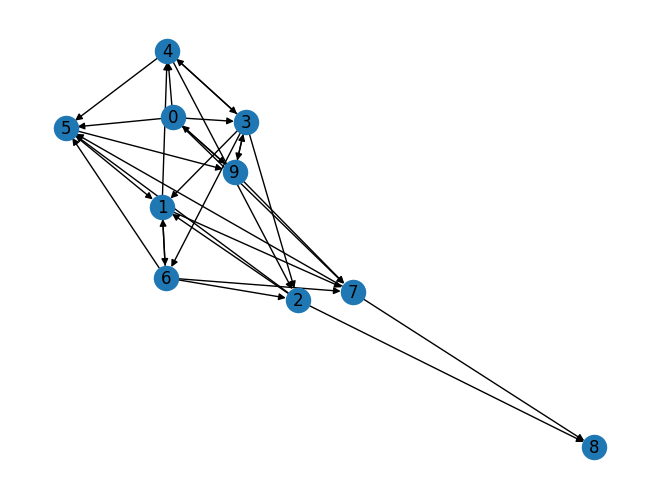

In [5]:
# 1. Create a directed graph with N nodes
N = 10
p = 0.3
g = nx.DiGraph()
g.add_nodes_from([i for i in range(N)])

# 2. Add random edges to the graph
g = add_edges(g, p)

# 3. Visualize the graph
nx.draw(g, with_labels=True)

In [6]:
# 3. Perform random walk
points = randome_walk(g)

In [7]:
# 4. Get nodes rank according to their random walk points
sorted_nodes = sort_nodes(g, points)
print("PageRank using random walk: ", sorted_nodes)

# 5. Get nodes rank according to inbuilt pagerank method
pr = nx.pagerank(g)
print("PageRank using inbuilt method: ", pr)

# 6. Compare the ranks
print("Comparing the ranks: ")
for i in range(N):
    print("Node: ", sorted_nodes[i], "RandomWalk: ", points[sorted_nodes[i]], "Inbuilt: ", pr[sorted_nodes[i]])


PageRank using random walk:  [5 1 7 9 8 4 3 6 2 0]
PageRank using inbuilt method:  {0: 0.054363985471488976, 1: 0.13974769566599474, 2: 0.07941786908478413, 3: 0.08827136294521568, 4: 0.08705395655953814, 5: 0.14704354059065966, 6: 0.0778120195137008, 7: 0.11973579649322993, 8: 0.09660102155738413, 9: 0.1099527521180038}
Comparing the ranks: 
Node:  5 RandomWalk:  15336 Inbuilt:  0.14704354059065966
Node:  1 RandomWalk:  14685 Inbuilt:  0.13974769566599474
Node:  7 RandomWalk:  12391 Inbuilt:  0.11973579649322993
Node:  9 RandomWalk:  11305 Inbuilt:  0.1099527521180038
Node:  8 RandomWalk:  9543 Inbuilt:  0.09660102155738413
Node:  4 RandomWalk:  8613 Inbuilt:  0.08705395655953814
Node:  3 RandomWalk:  8492 Inbuilt:  0.08827136294521568
Node:  6 RandomWalk:  7557 Inbuilt:  0.0778120195137008
Node:  2 RandomWalk:  7356 Inbuilt:  0.07941786908478413
Node:  0 RandomWalk:  4723 Inbuilt:  0.054363985471488976
